# Examen Data Science & AI

| | |
| :--- | :--- |
| **Examenreeks** | Voorbeeldexamen |
| **Student:** | VUL HIER JE NAAM IN |
| **Studentennummer:** | VUL HIER JE STUDENTENNUMMER IN |
| **Datum & uur:** | EXAMENDATUM, STARTUUR |
| **Klasgroep:** | VUL HIER JE KLASGROEP IN |
| **IOEM-student:** | NEE |

Add code cells where necessary to work out the questions. 

**CAUTION!** The contents of the code blocks are not considered answers! Only what you write down in the Markdown cells provided for that purpose counts as an answer! The content of the code blocks serves only to substantiate your answer so that we can see how you arrived at your answer if it would not match the expected outcome.

**DON'T FORGET THE SCREEN CAPTURE!!**

!! The exam will be in dutch for all students not enrolled in the IC !!

In [1]:
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation


## Question 1

The diameter of pistons produced in a factory are _D_ cm where _D_ ~ Nor(13.4, 0.12)

(1) The tolerance specified for the pistons is that the diameter needs to be at least 13.35 cm and not more than 13.5 cm. What proportion of the production in the factory meets these tolerance limits?  

In [3]:
mu = 13.4
sigma = 0.12

p = stats.norm.cdf(13.5, mu, sigma) - stats.norm.cdf(13.35, mu, sigma)
print(p)

0.4592104995256687


(2) Three pistons are chosen at random. What is the probability that none of them meet the tolerance limits  

In [4]:
print(1-p)

0.5407895004743313


(3) A sample of 20 pistons is taken at random. The mean value for the diameter is found to be 13.43 cm. Test at the 5% significance level whether any modifications have been made to the machine producing the pistons.

In [8]:
n = 20
mean = 13.43
alpha = 0.05

se = alpha / np.sqrt(n)

z = (mean - mu) / se

pwaarde = 2 * (1-stats.norm.cdf(abs(z)))
print(pwaarde)
if pwaarde < alpha:
    print("    Conclusie: Verwerp H0. Er is bewijs dat de machine is aangepast.")
else:
    print("    Conclusie: H0 niet verwerpen. Er is onvoldoende bewijs voor aanpassing.")

0.007290358091536886
    Conclusie: Verwerp H0. Er is bewijs dat de machine is aangepast.


## Question 2

The number of employees on the payroll at a food processing company is recorded at the beginning of each month.
These data are given below.

1. Give the data types of both columns
2. Convert the 'date' column to datetime type. Even if this fails you can continue working.
3. Create the following plot.

4. Make a forecast for the first four months of the next year using the most appropriate method. Explain why you chose this method.
5. Make a plot including the forecast.
6. Make the following calculations
- 6.1 Calculate the average number of employees in 2020
- 6.2 How many months did the company have more than 400 employees?




In [13]:
dfemployees = pd.DataFrame(data={
    'recording_date': ['2019/01/01', '2019/02/01', '2019/03/01', '2019/04/01', '2019/05/01', '2019/06/01', '2019/07/01', '2019/08/01', '2019/09/01', '2019/10/01', '2019/11/01', '2019/12/01', '2020/01/01', '2020/02/01', '2020/03/01', '2020/04/01', '2020/05/01', '2020/06/01', '2020/07/01', '2020/08/01', '2020/09/01', '2020/10/01', '2020/11/01', '2020/12/01', '2021/01/01', '2021/02/01', '2021/03/01', '2021/04/01', '2021/05/01', '2021/06/01', '2021/07/01', '2021/08/01', '2021/09/01', '2021/10/01', '2021/11/01', '2021/12/01'],
    'number': [350,348,353,353,349,377,375,403,412,409,398,357,349,351,350,355,346,377,372,405,416,407,399,355,347,351,350,352,343,374,375,408,412,410,400,357]
})
dfemployees.head()

,recording_date,number
0,2019/01/01,350
1,2019/02/01,348
2,2019/03/01,353
3,2019/04/01,353
4,2019/05/01,349


In [11]:
# 1. Give the data types of both columns
dfemployees.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   recording_date  36 non-null     str  
 1   number          36 non-null     int64
dtypes: int64(1), str(1)
memory usage: 708.0 bytes


In [12]:
# 2. Convert the 'date' column to datetime type. Even if this fails you can continue working.
dfemployees['recording_date'] = pd.to_datetime(dfemployees['recording_date'])
dfemployees.set_index('recording_date', inplace=True)

<Axes: >

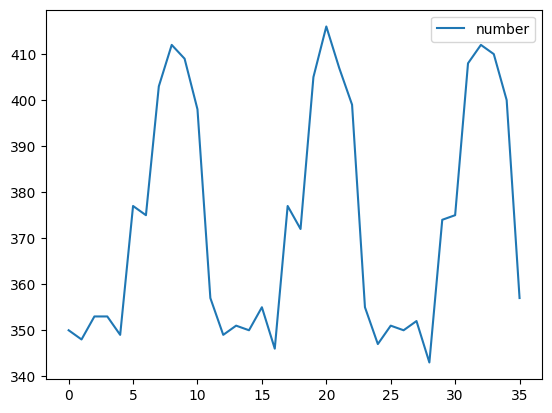

In [14]:
# 3. Create the plot.
dfemployees.plot(y='number')

In [16]:
# 4. Make a forecast for the first four months of the next year using the most appropriate method. Explain why you chose this method.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

data = ExponentialSmoothing(dfemployees['number'], seasonal='add', seasonal_periods=12)
model = data.fit()

forecast = model.forecast(4)

<Axes: >

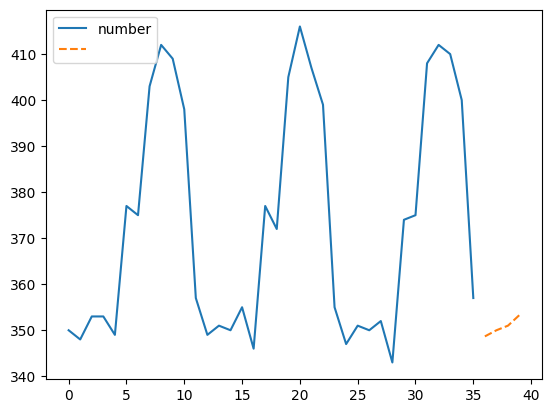

In [23]:
# 5. Make a plot including the forecast.
dfemployees['number'].plot(legend=True)
forecast.plot(legend=True,linestyle='--')

In [26]:
# 6. Make the following calculations
# - 6.1 Calculate the average number of employees in 2020
# 1. Zorg dat de datumindex goed staat
dfemployees['recording_date'] = pd.to_datetime(dfemployees['recording_date'])
dfemployees.set_index('recording_date', inplace=True)

# 2. Bereken het gemiddelde over 2020
# Nu we een echte DatetimeIndex hebben, werkt .loc['2020'] wel
avg_2020 = dfemployees.loc['2020']['number'].mean()
print(f"6.1 Gemiddeld aantal medewerkers in 2020: {avg_2020:.2f}")

# 3. Aantal maanden met meer dan 400 medewerkers
months_gt_400 = (dfemployees['number'] > 400).sum()
print(f"6.2 Aantal maanden met meer dan 400 medewerkers: {months_gt_400}")

6.1 Gemiddeld aantal medewerkers in 2020: 373.50
6.2 Aantal maanden met meer dan 400 medewerkers: 9


In [25]:
# - 6.2 How many months did the company have more than 400 employees?
months_gt_400 = (dfemployees['number'] > 400).sum()
print(f"6.2 Months with > 400 employees: {months_gt_400}")

6.2 Months with > 400 employees: 9


## Question 3

In the Flanders Travel Behavior Survey (2021-2022) (Onderzoek Verplaatsingsgedrag Vlaanderen), we find the following figures related to the distribution of driver's license ownership by net income at the person level for persons aged 18 and over (excluding schoolchildren and students).  Is there a relationship between income and whether or not one has a driver's license?

1. What hypothesis test will you apply to answer this research question? Be as specific as possible!
2. Formulate the null hypothesis and the alternative hypothesis
3. Calculate the appropriate test statistic (test statistic) for this test. Provide the symbol and value
4. Calculate the p-value
5. Draw a conclusion based on the previous step and formulate an answer to the research question.
6. What percentage of those surveyed do not have a driver's license?

In [2]:
dfdriverlicense = pd.DataFrame(data={
    'income': ['0 - 1000 EUR', '1001 - 1500 EUR', '1501 - 2000 EUR', '2001 - 2500 EUR', '2501 - 3000 EUR', '>3000 EUR', 'does not want to answer this question'],
    'yes': [149, 469, 800, 653, 325, 270, 230],
    'no': [61, 157, 55, 20, 10, 4, 51]}).set_index('income')

dfdriverlicense.head()
dfdriverlicense.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 0 - 1000 EUR to does not want to answer this question
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   yes     7 non-null      int64
 1   no      7 non-null      int64
dtypes: int64(2)
memory usage: 168.0+ bytes


<Axes: xlabel='income'>

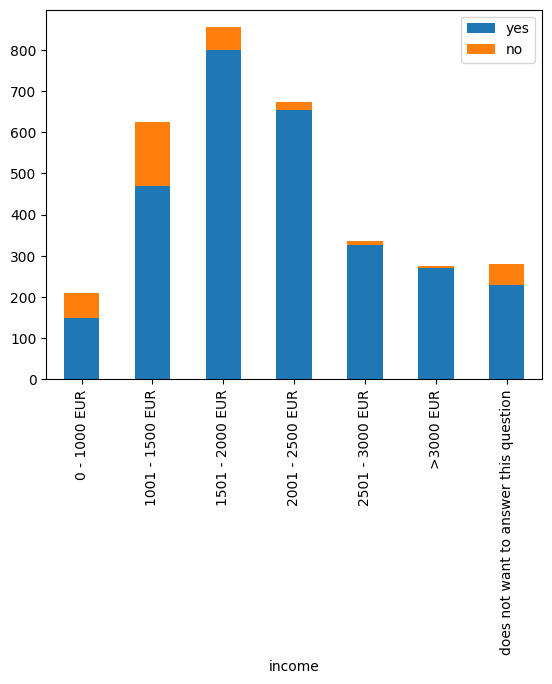

In [3]:
dfdriverlicense.plot(kind='bar', stacked=True)

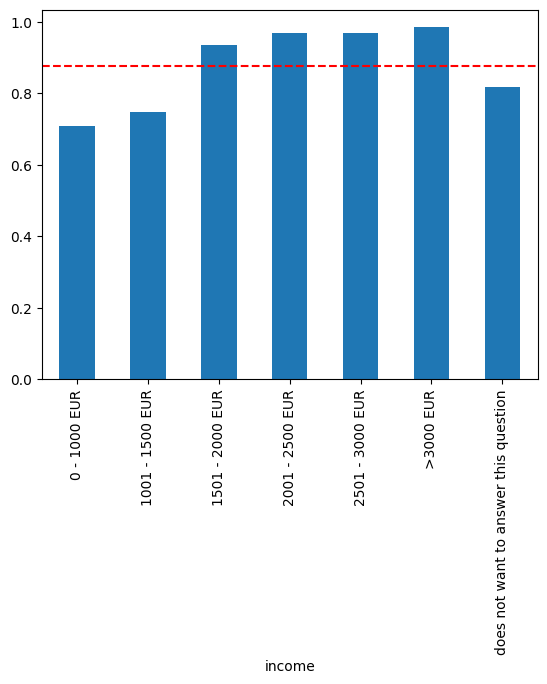

In [4]:
dfdriverlicense['prt_yes'] = dfdriverlicense['yes'] / (dfdriverlicense['yes'] + dfdriverlicense['no'])

dfdriverlicense.prt_yes.plot(kind='bar')

plt.axhline(y=dfdriverlicense['prt_yes'].mean(), color='red', linestyle='--')

In [5]:
expected = [dfdriverlicense['prt_yes'].mean()] * 7
stats.chisquare(f_obs=dfdriverlicense.prt_yes, f_exp=expected)


Power_divergenceResult(statistic=np.float64(0.09165059856640614), pvalue=np.float64(0.9999845027168809))

## Question 4

Below are the restaurant scores for a number of New York City (NYC) and Long Island (LI) restaurants.

1. First, based on the scores for *eat*, *decor* and *service*, calculate the *total score*. **If you cannot calculate the total score, continue working with the score for food.**
2. Create the plot below.

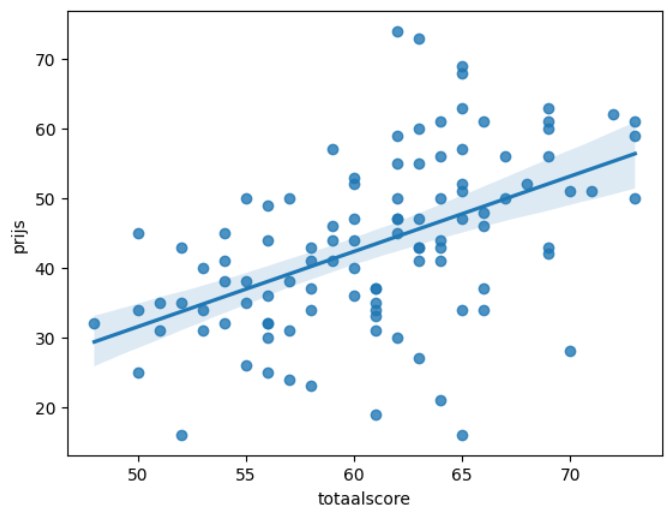

3. Use linear regression to try to predict the *price* based on the *total score*. Give the equation of the regression equation.
4. Give the estimated *price* for a *total score* = 70.
5. Calculate the correlation coefficient (symbol + value).
6. Give the interpretation for the value of the correlation coefficient.
7. List the number, minimum, maximum, mean, standard deviation, ... in the columns of quantitative variables.
8. The coefficient of variation is a dispersion measure that is independent of the unit in which data are expressed and is defined as the standard deviation divided by the mean. Calculate the coefficient of variation for *the score for eating*.
9. How many restaurants are there in New York City with a *price* higher than $65 (not including $65)?
10. Are *prices* in New York City significantly ($alpha = 0.05$) higher than in Long Island?

    - What statistical test will you use to determine this?
    - Formulate the null hypothesis and the alternative hypothesis
    - Calculate the excess probability $p$
    - Draw a conclusion based on this value and answer the research question.

In [27]:
dfrestaurants = pd.DataFrame(
    data={'restaurantname': ["101","12th St. Bar & Grill","202 Café","212","24 Prince","26 Seats","360","41 Greenwich Avenue","44","44 X Hell's Kitchen","5 Ninth","71 Irving Place","718","A.O.C.","A.O.C. Bedford","Abboccato","Abigael's","Above","Adrienne's Pizzabar","Aesop's Tables","Agata & Valentina Ristorante","Agave","Agnanti","Aix Brasserie","Aja","Aji Sushi","Areo","Bouley, Upstairs","Casa Mono","Cesca","Coals","Etats-Unis","Gari","Henry's End","ino","inoteca","Joya","Lupa","MarkJoseph Steakhouse","Noodle Pudding","Norma's","Osaka","Pearl Oyster Bar","Piccola Venezia","Po","Scalinatella","Sparks Steak House","Spigolo","Sushi Ann","Sushi Sen-nin","Tommaso","Wolfgang's Steakhouse","Yakitori Totto","105 Harbor","1770 House Restaurant & Inn","25 East American Bistro","56th Fighter Group","Abel Conklin's","Adirondack Grill","Akbar","Albert's Mandarin Gourmet","Allison's Ristorante","Almond","Amici","Aqua Blue Bar & Grill","Argyle Grill & Tavern","Ariana","Ayhan's Fish Kebab","Ayhan's Mediterranean Café","B. Smith's","Baang Café & Bar","Babylon Carriage House","Bamboo Restaurant & Sushi","Barney's","Barolo","Basil Leaf Café","Bay & Main","Bayou, The","Bayport House, The","Bayview Inn & Restaurant","Beacon","Bedlam Street Fish & Clam","Bella Vita City Grill","Bellport, The","Benihana","Benny's Ristorante","Maureen & Daughters Kitchen","Minami","Mirko's","Nisen","Palm","Plaza Café","Robert's","Rothmann's Steakhouse","Royal Tangra Masala","Sempre Vivolo","Soigne","Sole","Starr Boggs","Steve's Piccola Bussola","Stonewalls","Tellers American Chophouse","Trattoria Diane","Vine Street Café","Vintage Prime Steakhouse","Yuki's Palette"],
    'location': ["NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","NYC","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI","LI"],
    'food': [20,21,21,17,18,23,23,18,20,21,20,19,22,19,23,23,20,18,24,22,18,19,24,21,20,21,25,25,25,23,25,25,26,25,24,23,25,25,25,25,25,25,26,25,25,25,25,25,25,25,25,25,25,20,24,16,14,22,16,19,23,19,21,22,18,21,20,20,18,16,22,21,20,26,24,18,19,22,21,24,20,22,21,24,17,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25],
    'decor': [18,19,17,17,17,16,15,18,22,18,22,17,19,16,21,20,16,19,17,18,16,19,15,21,23,14,20,16,18,21,17,16,17,14,14,18,19,18,17,18,20,17,14,17,16,17,19,16,17,15,18,20,19,22,25,20,21,17,21,17,18,19,15,18,17,21,17,17,15,23,23,24,18,23,20,17,15,16,21,21,19,19,17,19,17,18,19,21,21,20,18,21,21,22,14,22,24,15,24,15,21,26,21,15,21,15],
    'service': [17,20,18,16,15,19,19,19,18,19,17,16,19,16,21,21,18,18,17,20,14,18,19,20,20,20,21,18,20,21,19,23,19,24,18,20,20,21,23,22,21,20,19,23,21,21,21,21,21,20,22,20,20,20,23,17,16,21,16,18,22,21,18,21,17,19,20,19,17,17,19,18,18,24,22,19,18,18,20,24,18,21,20,21,19,24,21,24,23,21,23,24,21,22,18,24,24,21,20,21,23,22,22,23,23,21],
    'price': [38,36,32,45,34,37,38,35,52,43,57,16,40,35,51,61,45,50,23,44,32,36,34,59,43,26,48,46,47,57,19,56,74,43,25,37,21,50,63,34,37,30,41,52,47,73,68,55,60,53,47,69,44,50,62,40,31,47,31,32,27,44,41,33,43,35,31,30,25,49,43,41,44,59,46,38,35,32,47,42,50,45,41,41,34,50,16,28,63,34,61,51,56,60,24,51,50,34,56,37,43,61,52,55,61,31]})


In [29]:
# 1. First, based on the scores for *eat*, *decor* and *service*, calculate the *total score*. **If you cannot calculate the total score, continue working with the score for food.**
dfrestaurants['totalscore'] = dfrestaurants['food'] + dfrestaurants['decor'] + dfrestaurants['service']

<Axes: >

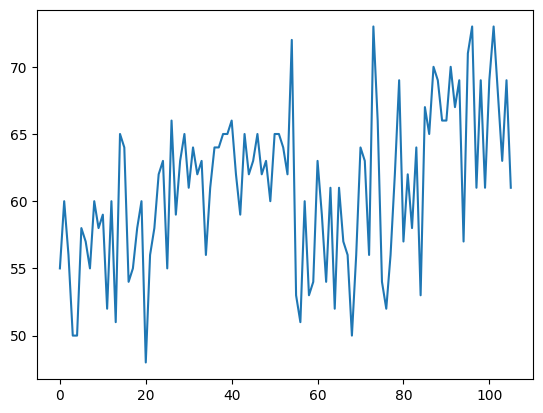

In [32]:
# 2. Create the plot below.
dfrestaurants['totalscore'].plot()

In [36]:
# 3. Use linear regression to try to predict the *price* based on the *total score*. Give the equation of the regression equation.
from sklearn.linear_model import LinearRegression

x = dfrestaurants[['totalscore']]
y = dfrestaurants['price']

model = LinearRegression().fit(x,y)
print(f"Regression line: ŷ = {model.intercept_:.4f} + {model.coef_[0]:.4f} x")

Regression line: ŷ = -22.5688 + 1.0817 x


In [48]:
# 4. Give the estimated *price* for a *total score* = 70.
model.predict([[70]])

/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53.15131255])

In [47]:
# 5. Calculate the correlation coefficient (symbol + value).
dfrestaurants['totalscore'].corr(dfrestaurants['price'])

np.float64(0.5035321564330562)

In [ ]:
# 6. Give the interpretation for the value of the correlation coefficient.


In [46]:
# 7. List the number, minimum, maximum, mean, standard deviation, ... in the columns of quantitative variables.
dfrestaurants[['food', 'decor', 'service', 'price', 'totalscore']].describe()

,food,decor,service,price,totalscore
count,106.000000,106.000000,106.000000,106.000000,106.000000
mean,22.471698,18.528302,19.990566,43.405660,60.990566
std,2.902241,2.712256,2.261459,12.411806,5.777617
min,14.000000,14.000000,14.000000,16.000000,48.000000
25%,20.000000,17.000000,18.000000,34.000000,56.250000
50%,23.500000,18.000000,20.000000,43.000000,61.500000
75%,25.000000,21.000000,21.000000,51.000000,65.000000
max,26.000000,26.000000,24.000000,74.000000,73.000000


In [ ]:
# 8. The coefficient of variation is a dispersion measure that is independent of the unit in which data are expressed and is defined as the standard deviation divided by the mean. Calculate the coefficient of variation for *the score for eating*.
dfrestaurants['food'].std() / dfrestaurants['food'].mean()

In [50]:
# 9. How many restaurants are there in New York City with a *price* higher than $65 (not including $65)?
dfrestaurants[(dfrestaurants['location'] == 'NYC') & (dfrestaurants['price'] > 65)].shape[0]

4

In [52]:
#10. Are *prices* in New York City significantly ($alpha = 0.05$) higher than in Long Island?

#    - What statistical test will you use to determine this?
#    - Formulate the null hypothesis and the alternative hypothesis
#    - Calculate the excess probability $p$
#    - Draw a conclusion based on this value and answer the research question.

nyc_prices = dfrestaurants[dfrestaurants['location'] == 'NYC']['price']
li_prices = dfrestaurants[dfrestaurants['location'] == 'LI']['price']
stats.ttest_ind(nyc_prices, li_prices, alternative='greater')

TtestResult(statistic=np.float64(0.585071488401949), pvalue=np.float64(0.279883460787158), df=np.float64(104.0))